# Collaborative / Debate RAG (Multi-Agent RAG Paradigm)

## Table of Contents
1. [What is Collaborative / Debate RAG?](#what-is-collaborative--debate-rag)
2. [How It Works - The Complete Process](#how-it-works---the-complete-process)
3. [Full Workflow Diagram](#full-workflow-diagram)
4. [Why and When to Use It](#why-and-when-to-use-it)
5. [Pros and Cons](#pros-and-cons)
6. [Building from Scratch in LangGraph](#building-from-scratch-in-langgraph)
7. [Real-World Case Study: Investment Committee Debate](#real-world-case-study-investment-committee-debate)

---

## What is Collaborative / Debate RAG?

**Collaborative / Debate RAG** is a multi-agent RAG paradigm where multiple specialized agents independently retrieve evidence from knowledge bases, then engage in **structured adversarial debate rounds** to stress-test, critique, and refine each other's findings before converging on a high-quality consensus answer.

### The Core Insight

Most RAG systems have a single retriever and a single generator. This creates a dangerous single-point-of-failure: if the retrieval is poor or the LLM hallucinates, there is no check. Collaborative Debate RAG solves this by introducing **cognitive diversity** — multiple agents with different analytical lenses independently gather evidence, then argue their positions in rounds. A neutral **Moderator** synthesizes the debate into a balanced final verdict.

Think of it like a **courtroom trial** or a **corporate board meeting**:
- The **Prosecution** (Bear Analyst) retrieves evidence of risk and argues against.
- The **Defense** (Bull Analyst) retrieves evidence of opportunity and argues for.
- The **Expert Witness** (Risk Analyst) retrieves regulatory/quantitative evidence and provides neutral context.
- The **Judge** (Moderator) listens to all rounds and delivers a balanced ruling.

### Key Terminology

| Term | Definition |
|------|-----------|
| **Debate Agent** | A specialized agent with a defined analytical perspective (e.g., bullish, bearish, risk-focused) |
| **Position Statement** | An agent's initial evidence-backed argument retrieved from its knowledge base |
| **Rebuttal** | A counter-argument where an agent challenges another agent's position using its own evidence |
| **Debate Round** | One full cycle where all agents present positions or rebuttals |
| **Convergence** | The point where agents' positions stabilize and no new substantive arguments emerge |
| **Moderator** | A neutral orchestrator agent that tracks the debate, checks for convergence, and synthesizes the final verdict |
| **Consensus Score** | A quantitative measure of how much the agents agree (used to determine when to stop debating) |

### How It Differs from Other Multi-Agent RAG Paradigms

| Feature | Hierarchical RAG | Sequential Multi-Hop RAG | Collaborative Debate RAG |
|---------|------------------|--------------------------|--------------------------|
| **Agent Relationship** | Boss -> Workers (top-down) | Analyst -> Executor (sequential loop) | Peers + Moderator (adversarial) |
| **Retrieval Pattern** | Parallel, independent | Sequential, dependent | Parallel, then adversarial cross-examination |
| **Key Mechanism** | Task decomposition & delegation | Bridge entities chain hops | Argumentation, rebuttal, convergence |
| **Failure Mode** | Worker returns bad data, boss trusts it | Wrong hop cascades errors | Debate catches errors via adversarial challenge |
| **Best For** | Multi-domain audits (breadth) | Chain-of-evidence (depth) | Contested decisions requiring balanced judgment |
| **Output Quality** | Good (parallel coverage) | Good (deep tracing) | Highest (adversarially stress-tested) |

---

## How It Works - The Complete Process

### Phase 1: Evidence Retrieval (Independent)

Each debate agent independently queries its own knowledge base to build its initial position. This is critical — agents must form opinions BEFORE seeing others' arguments, preventing groupthink.

```
User Question: "Should we invest $50M in QuantumTech Inc.?"

Bull Analyst  --> Queries Growth & Opportunity DB --> "Revenue up 28%, strong patent portfolio..."
Bear Analyst  --> Queries Risk & Liability DB     --> "FTC antitrust probe, sole-source dependency..."
Risk Analyst  --> Queries Regulatory & Quant DB   --> "Debt-to-equity 0.27, but ITAR compliance gaps..."
```

### Phase 2: Opening Statements (Round 1)

Each agent presents its evidence-backed position statement to the shared debate state. All agents can now see each other's arguments.

### Phase 3: Rebuttal Rounds (Rounds 2-N)

This is the core of the paradigm. In each round:

1. Each agent **reads the other agents' latest arguments**.
2. Each agent **challenges specific claims** using its own retrieved evidence.
3. Each agent **refines its own position** based on valid counter-arguments it received.
4. The **Moderator evaluates convergence** — are agents still introducing new substantive arguments, or are positions stabilizing?

Example rebuttal chain:
```
Bull: "Revenue grew 28% YoY — strong growth trajectory."
Bear: "But R&D spend is $52M against $38M EBITDA. They're burning cash to grow. Unsustainable."
Bull: "Fair point on burn rate, but their SaaS gross margin is 64.2% — unit economics are healthy."
Risk: "Both points valid. However, the FTC antitrust probe introduces regulatory uncertainty
       that could delay the CryoSystems acquisition, which is their key growth catalyst."
```

### Phase 4: Convergence Check

After each round, the Moderator analyzes whether:
- Agents are repeating arguments (convergence reached)
- All key dimensions have been covered
- The maximum number of rounds has been reached

### Phase 5: Final Verdict Synthesis

The Moderator compiles the full debate transcript into a structured verdict that:
- Summarizes each agent's strongest arguments
- Identifies points of agreement and disagreement
- Delivers a balanced, evidence-backed recommendation
- Assigns a confidence level to the final decision

---

## Full Workflow Diagram

### High-Level Architecture

```mermaid
graph TD
    subgraph Collaborative_Debate_RAG ["COLLABORATIVE DEBATE RAG"]
        Bull["Bull Analyst<br/>(Retrieves growth data)"]
        Bear["Bear Analyst<br/>(Retrieves risk data)"]
        Risk["Risk Analyst<br/>(Retrieves quant data)"]
        
        SharedState["SHARED DEBATE STATE<br/>(All positions, rebuttals, and evidence visible)"]
        
        Bull --> SharedState
        Bear --> SharedState
        Risk --> SharedState
        
        BullRebut["Bull Rebuttal<br/>(Challenges Bear & Risk)"]
        BearRebut["Bear Rebuttal<br/>(Challenges Bull & Risk)"]
        RiskRebut["Risk Rebuttal<br/>(Challenges Bull & Bear)"]
        
        SharedState --> BullRebut
        SharedState --> BearRebut
        SharedState --> RiskRebut
        
        Mod["MODERATOR<br/>(Convergence Check & Final Verdict)"]
        
        BullRebut --> Mod
        BearRebut --> Mod
        RiskRebut --> Mod
    end
```

### Detailed State Machine

```mermaid
stateDiagram-v2
    [*] --> BullRetrieve: START
    
    BullRetrieve: Bull Analyst (Retrieve & Present Opening Position)
    BullRetrieve --> BearRetrieve
    
    BearRetrieve: Bear Analyst (Retrieve & Present Opening Position)
    BearRetrieve --> RiskRetrieve
    
    RiskRetrieve: Risk Analyst (Retrieve & Present Opening Position)
    RiskRetrieve --> ModCheck
    
    ModCheck: Moderator (Check Convergence)
    ModCheck --> AllRebut: continue
    ModCheck --> ModVerdict: converged
    
    AllRebut: All Agents (Rebut Each Other's Claims - Next Round)
    AllRebut --> ModCheck2
    
    ModCheck2: Moderator (Check Convergence Again)
    ModCheck2 --> AllRebut: continue
    ModCheck2 --> ModVerdict: converged
    
    ModVerdict: Moderator (Final Verdict Synthesis)
    ModVerdict --> [*]: END
```

---

## Why and When to Use It

### When to Use Collaborative Debate RAG

1. **High-Stakes Decisions**: Investment decisions, medical diagnoses, legal judgments where a single perspective is dangerous.
2. **Contested or Ambiguous Questions**: Questions where reasonable people could disagree (e.g., "Is this acquisition a good idea?").
3. **Bias Mitigation**: When you need to actively counteract confirmation bias in retrieval and generation.
4. **Multi-Perspective Analysis**: Scenarios requiring explicit consideration of pros, cons, and risk factors.
5. **Regulatory / Compliance Reviews**: Where you must demonstrate that multiple angles were considered before a decision.

### When NOT to Use It

- **Simple factual lookups**: "What is the capital of France?" does not need a debate.
- **Undisputed, objective queries**: Questions with a single clear answer.
- **Latency-critical applications**: Multiple debate rounds add significant time.
- **Small knowledge bases**: Debate is only valuable when agents can retrieve genuinely different evidence.

---

## Pros and Cons

### Pros

| Advantage | Description |
|-----------|-------------|
| **Adversarial Error Correction** | Agents actively challenge each other's claims, catching hallucinations and retrieval errors |
| **Reduced Confirmation Bias** | Forcing opposing perspectives prevents the system from cherry-picking supporting evidence |
| **Higher Output Quality** | Final answers are stress-tested through multiple rounds of scrutiny |
| **Auditable Reasoning** | Full debate transcript provides a rich audit trail of how the decision was reached |
| **Cognitive Diversity** | Different analytical lenses (bull/bear/risk) ensure comprehensive coverage |
| **Graceful Uncertainty** | The system naturally expresses uncertainty when agents genuinely disagree |

### Cons

| Disadvantage | Description |
|--------------|-------------|
| **Highest Latency** | Multiple debate rounds with multiple agents is the slowest RAG paradigm |
| **Highest Token Cost** | Each agent makes multiple LLM calls per round, multiplied by number of rounds |
| **Complexity** | Most complex to implement — requires careful prompt engineering for each agent's persona |
| **Artificial Disagreement** | Agents may manufacture disagreements to "fill their role" even when evidence clearly supports one side |
| **Convergence Difficulty** | LLM-based agents may struggle to converge, requiring hard round limits |
| **Diminishing Returns** | After 2-3 rounds, additional debate rounds rarely produce new insights |

---

## Building from Scratch in LangGraph

### Step 1: Define the Debate State

```python
class DebateState(MessagesState):
    current_round: int           # Which debate round we are in
    max_rounds: int              # Maximum debate rounds allowed
    bull_position: str           # Bull analyst's current position
    bear_position: str           # Bear analyst's current position
    risk_position: str           # Risk analyst's current position
    debate_history: list[str]    # Full transcript of all rounds
    next_step: str               # "debate" or "verdict"
    final_verdict: str           # Moderator's final synthesis
```

### Step 2: Build Agent Nodes with Personas

Each agent has a defined analytical lens:

```python
def bull_analyst(state):
    """Retrieves and argues the BULLISH case — growth, opportunity, upside."""
    evidence = query_growth_database(state)
    other_positions = get_other_positions(state)
    
    if state["current_round"] == 1:
        position = llm.invoke("Present your BULLISH opening position based on: " + evidence)
    else:
        position = llm.invoke("REBUT the bear/risk arguments and strengthen your case: " + other_positions)
    
    return {"bull_position": position, "debate_history": [...updated]}
```

### Step 3: Build the Moderator with Convergence Detection

```python
def moderator(state):
    """Evaluates debate progress and decides whether to continue or deliver verdict."""
    decision = structured_llm.invoke(
        "Review the debate transcript. Are agents still making NEW substantive arguments? "
        "Or have positions stabilized? Decide: 'debate' (continue) or 'verdict' (synthesize)."
    )
    return {"next_step": decision.next_step}
```

### Step 4: Assemble the Graph

```python
graph = StateGraph(DebateState)
graph.add_node("bull_analyst", bull_analyst)
graph.add_node("bear_analyst", bear_analyst)
graph.add_node("risk_analyst", risk_analyst)
graph.add_node("moderator", moderator)
graph.add_node("verdict", final_verdict)

graph.add_edge(START, "bull_analyst")
graph.add_edge("bull_analyst", "bear_analyst")
graph.add_edge("bear_analyst", "risk_analyst")
graph.add_edge("risk_analyst", "moderator")
graph.add_conditional_edges("moderator", route_debate, {"debate": "bull_analyst", "verdict": "verdict"})
graph.add_edge("verdict", END)
```

---

## Real-World Case Study: Investment Committee Debate

### Scenario

A private equity fund, **Apex Capital Partners**, is evaluating a **$50 Million growth equity investment** in **QuantumTech Inc.**, a quantum computing startup. The fund's Investment Committee requires a structured adversarial review before any capital deployment.

### The Question

> "Should Apex Capital Partners invest $50M in QuantumTech Inc.'s Series C? Evaluate the growth opportunity, downside risks, and regulatory/quantitative risk factors. Provide a final investment recommendation."

### The Three Debate Agents

| Agent | Perspective | Knowledge Base | Goal |
|-------|------------|----------------|------|
| **Bull Analyst** | Optimistic / Growth | Revenue data, market size, patent portfolio, competitive moats | Argue FOR the investment |
| **Bear Analyst** | Pessimistic / Risk | Litigation, customer concentration, burn rate, competitive threats | Argue AGAINST the investment |
| **Risk Analyst** | Neutral / Quantitative | Regulatory filings, debt ratios, ITAR compliance, sanctions exposure | Provide unbiased risk metrics |

### Expected Debate Flow

```
Round 1 (Opening Statements):
  Bull: "28% revenue growth, 64% gross margins, 2 granted patents in silicon photonics..."
  Bear: "FTC antitrust probe, sole-source supplier dependency, $52M R&D burn..."
  Risk: "Debt-to-equity 0.27 (healthy), but ITAR compliance gaps and sanctions exposure via CryoSystems..."

Round 2 (Rebuttals):
  Bull: "The R&D burn is justified — they're building a patent moat. SaaS margins prove unit economics."
  Bear: "But the FTC probe could block their CryoSystems acquisition — their ENTIRE growth catalyst."
  Risk: "The CryoSystems parent company is OFAC-sanctioned. This creates ITAR supply chain risk."

Round 3 (Convergence):
  Bull: "I concede the CryoSystems risk. But the core technology is valuable even without that deal."
  Bear: "I concede strong margins. But without CryoSystems, their hardware roadmap stalls."
  Risk: "Both valid. Net risk: MEDIUM-HIGH. Investment viable with pre-closing conditions."

Moderator Verdict: CONDITIONAL INVEST with risk mitigation requirements.
```

### Implementation


## Complete Implementation Code

In [ ]:
"""
Collaborative / Debate RAG Pattern - LangGraph Implementation
===============================================================

This script implements the Collaborative Debate Multi-Agent RAG paradigm for an
Investment Committee scenario where three adversarial analysts debate whether to
invest in a target company.

Architecture:
- Bull Analyst: Retrieves growth/opportunity evidence, argues FOR the investment.
- Bear Analyst: Retrieves risk/liability evidence, argues AGAINST the investment.
- Risk Analyst: Retrieves regulatory/quantitative evidence, provides neutral risk assessment.
- Moderator: Tracks debate rounds, detects convergence, synthesizes final verdict.

Key Concepts:
- Adversarial Retrieval: Each agent queries a different knowledge base with a different analytical lens.
- Structured Debate Rounds: Agents see each other's arguments and provide evidence-backed rebuttals.
- Convergence Detection: Moderator uses structured output to decide when debate has stabilized.
- Cognitive Diversity: Opposing perspectives prevent confirmation bias and catch hallucinations.
"""


In [2]:

import os
from typing import Literal, List
from pydantic import BaseModel, Field
from dotenv import load_dotenv

from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langgraph.graph import StateGraph, START, END, MessagesState

# Load environment variables
# load_dotenv(dotenv_path=os.path.join(os.path.dirname(os.path.abspath(__file__)), '..', '.env'))
load_dotenv()


True

In [3]:

# ==============================================================================
# Dynamic Dual-Provider LLM Setup (OpenAI / Groq)
# ==============================================================================

if os.environ.get("OPENAI_API_KEY"):
    print("[INFO] Detected OpenAI API Key. Running with OpenAI (gpt-4o & gpt-4o-mini)...")
    from langchain_openai import ChatOpenAI
    debate_model = ChatOpenAI(model='gpt-4o', temperature=0.3)
    moderator_model = ChatOpenAI(model='gpt-4o', temperature=0)
elif os.environ.get("GROQ_API_KEY"):
    print("[INFO] Detected Groq API Key. Running with Groq (llama-3.3-70b-versatile)...")
    from langchain_groq import ChatGroq
    debate_model = ChatGroq(model='llama-3.3-70b-versatile', temperature=0.3)
    moderator_model = ChatGroq(model='llama-3.3-70b-versatile', temperature=0)
else:
    raise ValueError("Missing credentials. Set OPENAI_API_KEY or GROQ_API_KEY in your .env file.")


[INFO] Detected Groq API Key. Running with Groq (llama-3.3-70b-versatile)...


In [4]:

# ==============================================================================
# Step 1: Define Domain-Specific Knowledge Bases
# ==============================================================================

# Knowledge Base 1: Growth & Opportunity Data (Bull Analyst's source)
GROWTH_DB = [
    {
        "category": "Revenue Performance",
        "data": (
            "[SOURCE: SEC-10K-FY2025] QuantumTech Inc. FY2025 Revenue: $142.5M USD "
            "(up 28% YoY from $111.3M in FY2024). Enterprise quantum SaaS subscriptions "
            "drove 72% of total revenue. Net new ARR: $31.2M. Customer retention rate: 94.7%."
        )
    },
    {
        "category": "Gross Margins",
        "data": (
            "[SOURCE: SEC-10K-FY2025] Gross margin expanded to 64.2% in FY2025 "
            "(up from 58.1% in FY2024), driven by SaaS mix shift. Blended cost of revenue "
            "decreased 12% as cloud infrastructure was optimized."
        )
    },
    {
        "category": "Patent Portfolio",
        "data": (
            "[SOURCE: USPTO-PAT-DB] QuantumTech holds 14 granted US patents and 8 pending applications "
            "in silicon-photonics and quantum key distribution. Key patents US-11948271-B2 (silicon-integrated "
            "superconducting QKD transceiver) and US-12053910-B1 (cryogenic thermal isolation) represent "
            "foundational IP with no known prior art challenges. Patent portfolio valued at $85M by "
            "independent IP valuation firm Kroll."
        )
    },
    {
        "category": "Market Opportunity",
        "data": (
            "[SOURCE: McKinsey-Quantum-Report-2025] The global quantum computing market is projected "
            "to reach $65B by 2030 (CAGR 32%). QuantumTech is positioned in the fastest-growing segment "
            "(quantum-secure communications) with an estimated 18% market share in North America."
        )
    },
    {
        "category": "Competitive Moat",
        "data": (
            "[SOURCE: Gartner-MQ-2025] QuantumTech named a Leader in Gartner's Magic Quadrant for "
            "Quantum Computing Platforms (2025). Only 3 companies hold this designation. Key differentiator: "
            "vertically integrated from chip fabrication to SaaS delivery. Switching costs for enterprise "
            "customers estimated at $2.4M average."
        )
    },
]

# Knowledge Base 2: Risk & Liability Data (Bear Analyst's source)
RISK_DB = [
    {
        "category": "Litigation Risk",
        "data": (
            "[SOURCE: Delaware-Chancery-Court-CH-10922] CyberSec Global Corp filed a patent "
            "infringement suit against QuantumTech (Nov 2025), claiming patent US-11948271-B2 infringes "
            "CyberSec's US-10822194 (coherent optical ring resonators). If QuantumTech loses, damages "
            "estimated at $18-35M plus potential injunction on core product line."
        )
    },
    {
        "category": "Regulatory Risk",
        "data": (
            "[SOURCE: FTC-Antitrust-Docket-928] FTC Bureau of Competition opened preliminary "
            "investigation (Oct 2025) into QuantumTech's proposed $30M acquisition of CryoSystems Ltd. "
            "The FTC is evaluating whether this constitutes a vertical monopoly in the quantum supply chain. "
            "If blocked, QuantumTech loses its primary growth catalyst for hardware vertical integration."
        )
    },
    {
        "category": "Customer Concentration",
        "data": (
            "[SOURCE: SEC-10K-FY2025-RiskFactors] Top 3 customers (US DoD, Northrop Grumman, Lockheed Martin) "
            "represent 61% of total revenue. Loss of any single top-3 customer would reduce revenue by "
            "18-27%. All contracts are annual renewal with 90-day termination clauses."
        )
    },
    {
        "category": "Burn Rate & Cash Runway",
        "data": (
            "[SOURCE: SEC-10K-FY2025] R&D spending: $52.0M (36.5% of revenue). Operating cash burn: "
            "$13.8M in FY2025. Cash position: $45.2M. At current burn rate, runway is approximately "
            "39 months without additional financing. However, planned CryoSystems acquisition ($30M) "
            "would reduce runway to approximately 13 months."
        )
    },
    {
        "category": "Sole-Source Dependency",
        "data": (
            "[SOURCE: SupplyChain-Audit-2025] QuantumTech relies on CryoSystems Ltd. as SOLE SOURCE "
            "for radiation-hardened microprocessors (Contract DOD-SC-2024-4471). Lead time: 18 months. "
            "No qualified alternative supplier exists. Supply disruption would halt 100% of hardware production."
        )
    },
]

# Knowledge Base 3: Regulatory & Quantitative Data (Risk Analyst's source)
REGULATORY_DB = [
    {
        "category": "Financial Health Metrics",
        "data": (
            "[SOURCE: Bloomberg-Terminal-QT] QuantumTech Inc. Key Ratios (FY2025):\n"
            "- Debt-to-Equity: 0.27 (healthy, industry avg: 0.45)\n"
            "- Current Ratio: 3.76 (strong liquidity)\n"
            "- Interest Coverage: 8.2x (comfortable)\n"
            "- Price-to-Revenue: 12.4x (premium valuation)\n"
            "- EV/EBITDA: 18.7x (above industry median of 14.2x)"
        )
    },
    {
        "category": "ITAR Compliance Status",
        "data": (
            "[SOURCE: DDTC-Compliance-Review-2025] QuantumTech is registered with DDTC under ITAR. "
            "However, 2024 audit flagged 3 non-critical compliance gaps in technology transfer documentation "
            "for international sales. Corrective action plan submitted but not yet verified. "
            "A major ITAR violation could result in debarment from DoD contracts (61% of revenue)."
        )
    },
    {
        "category": "Sanctions Exposure",
        "data": (
            "[SOURCE: OFAC-Screening-Report] CryoSystems Ltd. (QuantumTech's sole-source supplier) "
            "is owned 78.3% by Vanguard Industrial Holdings S.A. (Luxembourg). Vanguard was designated "
            "under OFAC Executive Order 14071 (Belarus sanctions) on 2023-09-15. Vanguard operates "
            "subsidiaries in Belarus (VIH-Minsk), Crimea (VIH-Crimea), and Iran (VIH-Tehran). "
            "Transacting with sanctioned entities exposes QuantumTech to CAATSA secondary sanctions."
        )
    },
    {
        "category": "Comparable Transactions",
        "data": (
            "[SOURCE: PitchBook-Comps-2025] Recent comparable quantum computing deals:\n"
            "- IonQ Series D: $84M at $4.2B pre-money (2024)\n"
            "- Rigetti SPAC: $1.5B EV (2022, now trading at $620M)\n"
            "- PsiQuantum Series D: $450M at $3.15B (2024)\n"
            "QuantumTech's implied $500M pre-money at $50M Series C appears reasonable vs. comps, "
            "but 75% discount to IonQ raises questions about relative positioning."
        )
    },
]


In [5]:

# ==============================================================================
# Step 2: Define Retrieval Functions
# ==============================================================================

def retrieve_growth_evidence(query: str) -> str:
    """Retrieves from the Growth & Opportunity knowledge base."""
    results = []
    query_lower = query.lower()
    for record in GROWTH_DB:
        searchable = f"{record['category']} {record['data']}".lower()
        if any(term in searchable for term in query_lower.split() if len(term) > 3):
            results.append(f"[{record['category']}]\n{record['data']}")
    return "\n\n".join(results) if results else "No growth data found."


def retrieve_risk_evidence(query: str) -> str:
    """Retrieves from the Risk & Liability knowledge base."""
    results = []
    query_lower = query.lower()
    for record in RISK_DB:
        searchable = f"{record['category']} {record['data']}".lower()
        if any(term in searchable for term in query_lower.split() if len(term) > 3):
            results.append(f"[{record['category']}]\n{record['data']}")
    return "\n\n".join(results) if results else "No risk data found."


def retrieve_regulatory_evidence(query: str) -> str:
    """Retrieves from the Regulatory & Quantitative knowledge base."""
    results = []
    query_lower = query.lower()
    for record in REGULATORY_DB:
        searchable = f"{record['category']} {record['data']}".lower()
        if any(term in searchable for term in query_lower.split() if len(term) > 3):
            results.append(f"[{record['category']}]\n{record['data']}")
    return "\n\n".join(results) if results else "No regulatory data found."


In [6]:

# ==============================================================================
# Step 3: Define the Debate Graph State
# ==============================================================================

class DebateState(MessagesState):
    """State for the collaborative debate RAG system."""
    current_round: int         # Which debate round (starts at 1)
    max_rounds: int            # Maximum debate rounds (default: 3)
    bull_position: str         # Bull analyst's current argument
    bear_position: str         # Bear analyst's current argument
    risk_position: str         # Risk analyst's current argument
    debate_transcript: list    # Full history of all debate entries
    next_step: str             # "debate" or "verdict"
    final_verdict: str         # Moderator's final synthesis



In [7]:

# ==============================================================================
# Step 4: Define Moderator's Convergence Schema
# ==============================================================================

class ConvergenceDecision(BaseModel):
    """Structured output for the Moderator's convergence check."""
    next_step: Literal["debate", "verdict"] = Field(
        description="Choose 'debate' if agents are still making new substantive arguments. Choose 'verdict' if positions have stabilized or all key dimensions are covered."
    )
    reasoning: str = Field(
        description="Explain why the debate should continue or why convergence has been reached."
    )
    agreement_areas: str = Field(
        default="",
        description="Key points where all agents agree."
    )
    disagreement_areas: str = Field(
        default="",
        description="Key points where agents still fundamentally disagree."
    )

structured_moderator = moderator_model.with_structured_output(ConvergenceDecision)

In [8]:


# ==============================================================================
# Step 5: Implement Debate Agent Nodes
# ==============================================================================

def bull_analyst_node(state: DebateState) -> dict:
    """Bull Analyst: Retrieves growth evidence and argues FOR the investment."""
    current_round = state.get("current_round", 1)
    transcript = state.get("debate_transcript", [])

    print(f"\n{'=' * 60}")
    print(f"[BULL ANALYST] Round {current_round}")

    # Retrieve evidence
    evidence = retrieve_growth_evidence("QuantumTech revenue growth patent market opportunity margins")

    if current_round == 1:
        # Opening statement
        prompt = (
            "You are the BULL ANALYST on an investment committee. Your role is to argue "
            "FOR investing in QuantumTech Inc.\n\n"
            "Based on the following evidence, present your OPENING POSITION making the "
            "strongest possible case for investment. Be specific with numbers and citations.\n\n"
            f"EVIDENCE:\n{evidence}\n\n"
            "Present a compelling, evidence-backed bullish argument (3-4 key points)."
        )
    else:
        # Rebuttal round
        bear_pos = state.get("bear_position", "")
        risk_pos = state.get("risk_position", "")
        prompt = (
            "You are the BULL ANALYST. You have seen the other analysts' arguments.\n\n"
            f"BEAR ANALYST's argument:\n{bear_pos}\n\n"
            f"RISK ANALYST's argument:\n{risk_pos}\n\n"
            f"YOUR EVIDENCE:\n{evidence}\n\n"
            "REBUT their specific concerns using your evidence. Acknowledge valid points "
            "but argue why the investment case remains strong. Be specific and cite sources."
        )

    response = debate_model.invoke([HumanMessage(content=prompt)])
    position = response.content

    print(f"   Position: {position[:200]}...")

    entry = f"[Round {current_round}] BULL ANALYST:\n{position}"

    return {
        "bull_position": position,
        "debate_transcript": transcript + [entry],
        "messages": [AIMessage(content=entry, name="BullAnalyst")]
    }


def bear_analyst_node(state: DebateState) -> dict:
    """Bear Analyst: Retrieves risk evidence and argues AGAINST the investment."""
    current_round = state.get("current_round", 1)
    transcript = state.get("debate_transcript", [])

    print(f"\n{'=' * 60}")
    print(f"[BEAR ANALYST] Round {current_round}")

    # Retrieve evidence
    evidence = retrieve_risk_evidence("QuantumTech litigation risk burn rate customer concentration supplier dependency")

    if current_round == 1:
        prompt = (
            "You are the BEAR ANALYST on an investment committee. Your role is to argue "
            "AGAINST investing in QuantumTech Inc.\n\n"
            "Based on the following evidence, present your OPENING POSITION making the "
            "strongest possible case AGAINST investment. Be specific with numbers and citations.\n\n"
            f"EVIDENCE:\n{evidence}\n\n"
            "Present a compelling, evidence-backed bearish argument (3-4 key points)."
        )
    else:
        bull_pos = state.get("bull_position", "")
        risk_pos = state.get("risk_position", "")
        prompt = (
            "You are the BEAR ANALYST. You have seen the other analysts' arguments.\n\n"
            f"BULL ANALYST's argument:\n{bull_pos}\n\n"
            f"RISK ANALYST's argument:\n{risk_pos}\n\n"
            f"YOUR EVIDENCE:\n{evidence}\n\n"
            "REBUT the bull's optimistic claims using your evidence. Acknowledge valid points "
            "but argue why the risks outweigh the opportunity. Be specific and cite sources."
        )

    response = debate_model.invoke([HumanMessage(content=prompt)])
    position = response.content

    print(f"   Position: {position[:200]}...")

    entry = f"[Round {current_round}] BEAR ANALYST:\n{position}"

    return {
        "bear_position": position,
        "debate_transcript": transcript + [entry],
        "messages": [AIMessage(content=entry, name="BearAnalyst")]
    }


def risk_analyst_node(state: DebateState) -> dict:
    """Risk Analyst: Retrieves regulatory/quantitative evidence, provides neutral assessment."""
    current_round = state.get("current_round", 1)
    transcript = state.get("debate_transcript", [])

    print(f"\n{'=' * 60}")
    print(f"[RISK ANALYST] Round {current_round}")

    # Retrieve evidence
    evidence = retrieve_regulatory_evidence("QuantumTech financial ratios ITAR compliance sanctions OFAC valuation")

    if current_round == 1:
        prompt = (
            "You are the RISK ANALYST on an investment committee. Your role is to provide "
            "a NEUTRAL, quantitative risk assessment of investing in QuantumTech Inc.\n\n"
            "Based on the following evidence, present your OPENING POSITION with key risk "
            "metrics, regulatory flags, and valuation context. Do NOT take a bull or bear side.\n\n"
            f"EVIDENCE:\n{evidence}\n\n"
            "Present a balanced, data-driven risk assessment (3-4 key points with specific metrics)."
        )
    else:
        bull_pos = state.get("bull_position", "")
        bear_pos = state.get("bear_position", "")
        prompt = (
            "You are the RISK ANALYST. You have seen both sides of the debate.\n\n"
            f"BULL ANALYST's argument:\n{bull_pos}\n\n"
            f"BEAR ANALYST's argument:\n{bear_pos}\n\n"
            f"YOUR EVIDENCE:\n{evidence}\n\n"
            "Evaluate BOTH arguments against your quantitative evidence. Identify which claims "
            "are supported by data and which are not. Provide updated risk metrics. Be neutral."
        )

    response = debate_model.invoke([HumanMessage(content=prompt)])
    position = response.content

    print(f"   Position: {position[:200]}...")

    entry = f"[Round {current_round}] RISK ANALYST:\n{position}"

    return {
        "risk_position": position,
        "debate_transcript": transcript + [entry],
        "messages": [AIMessage(content=entry, name="RiskAnalyst")]
    }


In [9]:

# ==============================================================================
# Step 6: Implement Moderator Node
# ==============================================================================

def moderator_node(state: DebateState) -> dict:
    """Moderator: Checks for debate convergence and decides whether to continue or synthesize."""
    current_round = state.get("current_round", 1)
    max_rounds = state.get("max_rounds", 3)
    transcript = state.get("debate_transcript", [])

    print(f"\n{'=' * 60}")
    print(f"[MODERATOR] Evaluating Round {current_round}...")

    # Force verdict if max rounds reached
    if current_round >= max_rounds:
        print(f"   Maximum rounds ({max_rounds}) reached. Forcing verdict.")
        return {
            "next_step": "verdict",
            "current_round": current_round + 1,
        }

    # Build transcript summary for moderator
    recent_entries = transcript[-3:] if len(transcript) >= 3 else transcript
    transcript_text = "\n\n".join(recent_entries)

    prompt = SystemMessage(content=(
        "You are the MODERATOR of an investment committee debate. Review the latest "
        "round of arguments from all three analysts.\n\n"
        f"LATEST ROUND ARGUMENTS:\n{transcript_text}\n\n"
        "EVALUATE:\n"
        "1. Are agents still introducing NEW substantive arguments or evidence?\n"
        "2. Have the core positions stabilized (agents are refining, not introducing new points)?\n"
        "3. Have all key dimensions been covered (growth, risk, regulatory)?\n\n"
        "If positions are still evolving with new evidence, choose 'debate'.\n"
        "If positions have converged or all dimensions are covered, choose 'verdict'."
    ))

    decision = structured_moderator.invoke([prompt])

    print(f"   Decision: {decision.next_step.upper()}")
    print(f"   Reasoning: {decision.reasoning}")
    if decision.agreement_areas:
        print(f"   Agreements: {decision.agreement_areas[:150]}")
    if decision.disagreement_areas:
        print(f"   Disagreements: {decision.disagreement_areas[:150]}")

    return {
        "next_step": decision.next_step,
        "current_round": current_round + 1,
    }



In [10]:

# ==============================================================================
# Step 7: Implement Final Verdict Node
# ==============================================================================

def final_verdict_node(state: DebateState) -> dict:
    """Moderator synthesizes the full debate into a structured investment verdict."""
    transcript = state.get("debate_transcript", [])
    total_rounds = state.get("current_round", 1) - 1

    print(f"\n{'=' * 60}")
    print("[MODERATOR] Synthesizing final investment verdict...")

    full_transcript = "\n\n".join(transcript)

    prompt = SystemMessage(content=(
        "You are the MODERATOR delivering the FINAL INVESTMENT VERDICT after a structured "
        "adversarial debate. You must be balanced, evidence-based, and decisive.\n\n"
        f"FULL DEBATE TRANSCRIPT ({total_rounds} rounds):\n{full_transcript}\n\n"
        "COMPILE YOUR VERDICT WITH THIS STRUCTURE:\n\n"
        "1. EXECUTIVE SUMMARY - One paragraph verdict with clear recommendation\n"
        "2. BULL CASE SUMMARY - Strongest arguments FOR (with source citations)\n"
        "3. BEAR CASE SUMMARY - Strongest arguments AGAINST (with source citations)\n"
        "4. RISK ASSESSMENT - Key quantitative metrics and regulatory flags\n"
        "5. POINTS OF CONSENSUS - Where all analysts agreed\n"
        "6. UNRESOLVED DISPUTES - Where analysts fundamentally disagreed\n"
        "7. FINAL RECOMMENDATION - INVEST / CONDITIONAL INVEST / PASS with clear conditions\n"
        "8. CONFIDENCE LEVEL - How confident is this recommendation (HIGH/MEDIUM/LOW)\n\n"
        "Be specific. Cite sources. This verdict must be audit-ready for the fund's LP reporting."
    ))

    response = moderator_model.invoke([prompt] + state["messages"])

    return {
        "final_verdict": response.content,
        "messages": [AIMessage(content=response.content, name="Moderator")]
    }



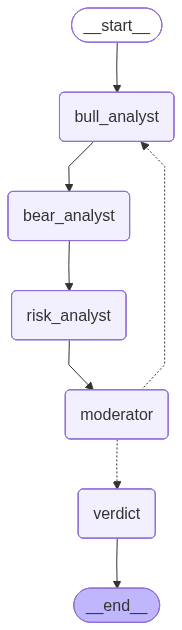

In [11]:

# ==============================================================================
# Step 8: Build Conditional Router and Assemble the Graph
# ==============================================================================

def route_moderator_decision(state: DebateState) -> str:
    """Routes based on the moderator's convergence decision."""
    if state.get("next_step") == "verdict":
        return "verdict"
    return "bull_analyst"  # Start next debate round


# Build the graph
workflow = StateGraph(DebateState)

# Add nodes
workflow.add_node("bull_analyst", bull_analyst_node)
workflow.add_node("bear_analyst", bear_analyst_node)
workflow.add_node("risk_analyst", risk_analyst_node)
workflow.add_node("moderator", moderator_node)
workflow.add_node("verdict", final_verdict_node)

# Wire edges: START -> Bull -> Bear -> Risk -> Moderator -> (loop or verdict)
workflow.add_edge(START, "bull_analyst")
workflow.add_edge("bull_analyst", "bear_analyst")
workflow.add_edge("bear_analyst", "risk_analyst")
workflow.add_edge("risk_analyst", "moderator")
workflow.add_conditional_edges(
    "moderator",
    route_moderator_decision,
    {
        "bull_analyst": "bull_analyst",
        "verdict": "verdict",
    }
)
workflow.add_edge("verdict", END)

# Compile
compiled_debate = workflow.compile()
compiled_debate


In [13]:

# ==============================================================================
# Step 9: Execute the Investment Committee Debate
# ==============================================================================

if __name__ == "__main__":
    print("\n" + "=" * 80)
    print("COLLABORATIVE DEBATE RAG - Investment Committee Analysis")
    print("=" * 80)

    user_query = (
        "Should Apex Capital Partners invest $50M in QuantumTech Inc.'s Series C? "
        "Evaluate the growth opportunity, downside risks, and regulatory/quantitative "
        "risk factors. Provide a final investment recommendation."
    )

    print(f"\nInvestment Question:\n\"{user_query}\"\n")

    # Initialize state
    inputs = {
        "messages": [HumanMessage(content=user_query)],
        "current_round": 1,
        "max_rounds": 3,
        "bull_position": "",
        "bear_position": "",
        "risk_position": "",
        "debate_transcript": [],
        "next_step": "debate",
        "final_verdict": "",
    }

    # Run the debate
    result = compiled_debate.invoke(inputs, {"recursion_limit": 30})

    # Print final verdict
    print("\n" + "=" * 80)
    print("FINAL INVESTMENT COMMITTEE VERDICT")
    print("=" * 80)
    print(result.get("final_verdict", result["messages"][-1].content))
    print("=" * 80)

    # Print debate statistics
    transcript = result.get("debate_transcript", [])
    print(f"\nDEBATE STATISTICS")
    print("=" * 80)
    print(f"Total debate entries: {len(transcript)}")
    print(f"Rounds completed: {result.get('current_round', 1) - 1}")

    bull_entries = [t for t in transcript if "BULL" in t[:30]]
    bear_entries = [t for t in transcript if "BEAR" in t[:30]]
    risk_entries = [t for t in transcript if "RISK" in t[:30]]
    print(f"Bull arguments: {len(bull_entries)}")
    print(f"Bear arguments: {len(bear_entries)}")
    print(f"Risk assessments: {len(risk_entries)}")

    # Context footprint
    print(f"\nCONTEXT FOOTPRINT ANALYSIS")
    print("=" * 80)
    total_chars = 0
    for idx, msg in enumerate(result["messages"]):
        name = getattr(msg, "name", None) or "User"
        content_len = len(msg.content) if msg.content else 0
        total_chars += content_len
        print(f"[{idx+1:02d}] {name:<16}: {content_len:<5} characters")
    print(f"\nTotal characters in message state: {total_chars}")
    print("=" * 80 + "\n")



COLLABORATIVE DEBATE RAG - Investment Committee Analysis

Investment Question:
"Should Apex Capital Partners invest $50M in QuantumTech Inc.'s Series C? Evaluate the growth opportunity, downside risks, and regulatory/quantitative risk factors. Provide a final investment recommendation."


[BULL ANALYST] Round 1
   Position: As the BULL ANALYST, I strongly advocate for investing in QuantumTech Inc. based on the following key points:

1. **Impressive Revenue Growth and Customer Retention**: QuantumTech's FY2025 revenue of ...

[BEAR ANALYST] Round 1
   Position: As the BEAR ANALYST, I strongly advise against investing in QuantumTech Inc. due to the following key concerns:

1. **Litigation Risk and Potential Injunction**: The patent infringement lawsuit filed ...

[RISK ANALYST] Round 1
   Position: **Neutral Risk Assessment: QuantumTech Inc.**

As the Risk Analyst, I present the following key risk metrics, regulatory flags, and valuation context for investing in QuantumTech Inc.:

1. **